In [1]:
# Phase A: Imports and project paths

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    f1_score,
    classification_report,
    average_precision_score
)

# Make pandas display a bit cleaner
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

# Project root detection that works whether the notebook is launched
# from the project root or from the notebooks folder
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = PROJECT_ROOT / "figures"

RESULTS_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Data dir exists:", DATA_DIR.exists()) 

Project root: c:\Users\farha\code\classical model vs fine tuned transformer vs LLM prompting
Data dir exists: True


In [2]:
# Phase B: Load the main labelled dataset

train_path = DATA_DIR / "train.csv"
df = pd.read_csv(train_path)

print("Shape:", df.shape)
df.head()

Shape: (159571, 8)


,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [3]:
# Phase C: Inspect columns, missing values, and basic structure

print("Columns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isna().sum())

print("\nSample rows:")
display(df.sample(5, random_state=42))

Columns:
['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

Missing values:
id               0
comment_text     0
toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
dtype: int64

Sample rows:


,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
119105,7ca72b5b9c688e9e,"Geez, are you forgetful! We've already discus...",0,0,0,0,0,0
131631,c03f72fd8f8bf54f,Carioca RFA \n\nThanks for your support on my ...,0,0,0,0,0,0
125326,9e5b8e8fc1ff2e84,"""\n\n Birthday \n\nNo worries, It's what I do ...",0,0,0,0,0,0
111256,5332799e706665a6,Pseudoscience category? \n\nI'm assuming that ...,0,0,0,0,0,0
83590,dfa7d8f0b4366680,"(and if such phrase exists, it would be provid...",0,0,0,0,0,0


In [4]:
# Phase D: Explore the label distribution and multi-label structure

label_cols = ["toxic", "severe_toxic", "obscene", "threat", "insult", "identity_hate"]

label_counts = df[label_cols].sum().sort_values(ascending=False)
print("Label counts:")
display(label_counts.to_frame(name="count"))

# Count how many labels each comment has
df["label_count"] = df[label_cols].sum(axis=1)

num_no_label = (df["label_count"] == 0).sum()
num_single_label = (df["label_count"] == 1).sum()
num_multi_label = (df["label_count"] > 1).sum()

summary_df = pd.DataFrame({
    "group": ["No labels", "Single label", "Multiple labels"],
    "count": [num_no_label, num_single_label, num_multi_label]
})

display(summary_df)

Label counts:


,count
toxic,15294
obscene,8449
insult,7877
severe_toxic,1595
identity_hate,1405
threat,478


,group,count
0,No labels,143346
1,Single label,6360
2,Multiple labels,9865


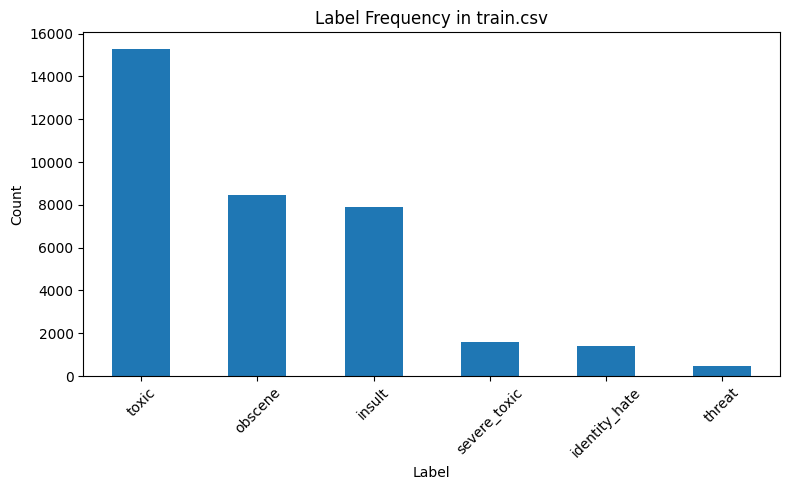

Saved figure to: c:\Users\farha\code\classical model vs fine tuned transformer vs LLM prompting\figures\label_frequency_train.png


In [5]:
# Phase E: Create a simple figure for label frequencies

plt.figure(figsize=(8, 5))
label_counts.plot(kind="bar")
plt.title("Label Frequency in train.csv")
plt.xlabel("Label")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()

figure_path = FIGURES_DIR / "label_frequency_train.png"
plt.savefig(figure_path, dpi=300)
plt.show()

print("Saved figure to:", figure_path)

In [6]:
# Phase F: Light preprocessing while preserving useful linguistic signals

df["comment_text"] = df["comment_text"].fillna("").astype(str)

# Keep the original text mostly intact.
# We only normalize obvious whitespace issues here.
df["comment_text"] = df["comment_text"].str.replace(r"\s+", " ", regex=True).str.strip()

# Optional sanity check
empty_comments = (df["comment_text"] == "").sum()
print("Empty comments after cleaning:", empty_comments)

Empty comments after cleaning: 0


In [7]:
# Phase G: Create train/validation/test splits
# We use approximate stratification based on whether a comment has any toxic label.

df["has_any_label"] = (df[label_cols].sum(axis=1) > 0).astype(int)

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=42,
    stratify=df["has_any_label"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["has_any_label"]
)

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

# Save splits for later notebooks
train_split_path = DATA_DIR / "train_split.csv"
val_split_path = DATA_DIR / "val_split.csv"
test_split_path = DATA_DIR / "test_split.csv"

train_df.to_csv(train_split_path, index=False)
val_df.to_csv(val_split_path, index=False)
test_df.to_csv(test_split_path, index=False)

print("Saved:")
print(train_split_path)
print(val_split_path)
print(test_split_path)

Train shape: (111699, 10)
Validation shape: (23936, 10)
Test shape: (23936, 10)
Saved:
c:\Users\farha\code\classical model vs fine tuned transformer vs LLM prompting\data\train_split.csv
c:\Users\farha\code\classical model vs fine tuned transformer vs LLM prompting\data\val_split.csv
c:\Users\farha\code\classical model vs fine tuned transformer vs LLM prompting\data\test_split.csv


In [8]:
# Phase H: Separate text inputs and label outputs

X_train = train_df["comment_text"]
X_val = val_df["comment_text"]
X_test = test_df["comment_text"]

y_train = train_df[label_cols].values
y_val = val_df[label_cols].values
y_test = test_df[label_cols].values

print("X_train size:", len(X_train))
print("y_train shape:", y_train.shape)

X_train size: 111699
y_train shape: (111699, 6)


In [9]:
# Phase I: Build TF-IDF features for the classical baseline

vectorizer = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2),
    max_features=30000,
    min_df=2,
    sublinear_tf=True
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf = vectorizer.transform(X_val)
X_test_tfidf = vectorizer.transform(X_test)

print("Train TF-IDF shape:", X_train_tfidf.shape)
print("Validation TF-IDF shape:", X_val_tfidf.shape)
print("Test TF-IDF shape:", X_test_tfidf.shape)

Train TF-IDF shape: (111699, 30000)
Validation TF-IDF shape: (23936, 30000)
Test TF-IDF shape: (23936, 30000)


In [10]:
# Phase J: Train TF-IDF + One-vs-Rest Logistic Regression

classical_model = OneVsRestClassifier(
    LogisticRegression(
        max_iter=1000,
        solver="liblinear"
    )
)

classical_model.fit(X_train_tfidf, y_train)

print("Classical baseline training complete.")

Classical baseline training complete.


In [11]:
# Phase K: Generate probability outputs for threshold tuning and evaluation

val_probs = classical_model.predict_proba(X_val_tfidf)
test_probs = classical_model.predict_proba(X_test_tfidf)

print("Validation probabilities shape:", val_probs.shape)
print("Test probabilities shape:", test_probs.shape)

Validation probabilities shape: (23936, 6)
Test probabilities shape: (23936, 6)


In [12]:
# Phase L: Tune one threshold per label using validation F1

threshold_grid = np.arange(0.10, 0.91, 0.05)
best_thresholds = {}

for i, label in enumerate(label_cols):
    best_f1 = -1
    best_threshold = 0.5
    
    for threshold in threshold_grid:
        preds = (val_probs[:, i] >= threshold).astype(int)
        score = f1_score(y_val[:, i], preds, zero_division=0)
        
        if score > best_f1:
            best_f1 = score
            best_threshold = threshold
    
    best_thresholds[label] = best_threshold

threshold_df = pd.DataFrame({
    "label": list(best_thresholds.keys()),
    "best_threshold": list(best_thresholds.values())
})

display(threshold_df)

threshold_path = RESULTS_DIR / "classical_best_thresholds.csv"
threshold_df.to_csv(threshold_path, index=False)
print("Saved thresholds to:", threshold_path)

,label,best_threshold
0,toxic,0.25
1,severe_toxic,0.15
2,obscene,0.25
3,threat,0.10
4,insult,0.20
5,identity_hate,0.20


Saved thresholds to: c:\Users\farha\code\classical model vs fine tuned transformer vs LLM prompting\results\classical_best_thresholds.csv


In [13]:
# Phase M: Convert probabilities into final binary predictions using tuned thresholds

test_preds = np.zeros_like(test_probs, dtype=int)

for i, label in enumerate(label_cols):
    threshold = best_thresholds[label]
    test_preds[:, i] = (test_probs[:, i] >= threshold).astype(int)

print("Test prediction matrix shape:", test_preds.shape)

Test prediction matrix shape: (23936, 6)


In [14]:
# Phase N: Compute overall metrics

micro_f1 = f1_score(y_test, test_preds, average="micro", zero_division=0)
macro_f1 = f1_score(y_test, test_preds, average="macro", zero_division=0)

# Average Precision / PR-AUC per label
pr_auc_per_label = {}
for i, label in enumerate(label_cols):
    pr_auc_per_label[label] = average_precision_score(y_test[:, i], test_probs[:, i])

mean_pr_auc = np.mean(list(pr_auc_per_label.values()))

overall_metrics = pd.DataFrame({
    "metric": ["micro_f1", "macro_f1", "mean_pr_auc"],
    "value": [micro_f1, macro_f1, mean_pr_auc]
})

display(overall_metrics)

,metric,value
0,micro_f1,0.730514
1,macro_f1,0.604852
2,mean_pr_auc,0.634141


In [15]:
# Phase O: Compute per-label metrics

per_label_rows = []

for i, label in enumerate(label_cols):
    label_f1 = f1_score(y_test[:, i], test_preds[:, i], zero_division=0)
    label_pr_auc = average_precision_score(y_test[:, i], test_probs[:, i])
    
    per_label_rows.append({
        "label": label,
        "f1": label_f1,
        "pr_auc": label_pr_auc
    })

per_label_metrics = pd.DataFrame(per_label_rows)
display(per_label_metrics)

,label,f1,pr_auc
0,toxic,0.765929,0.851492
1,severe_toxic,0.489564,0.435087
2,obscene,0.795312,0.866273
3,threat,0.421053,0.442178
4,insult,0.709495,0.767841
5,identity_hate,0.447761,0.441974


In [16]:
# Phase P: Save outputs for the paper and later notebooks

overall_metrics_path = RESULTS_DIR / "classical_overall_metrics.csv"
per_label_metrics_path = RESULTS_DIR / "classical_per_label_metrics.csv"
predictions_path = RESULTS_DIR / "classical_test_predictions.csv"

overall_metrics.to_csv(overall_metrics_path, index=False)
per_label_metrics.to_csv(per_label_metrics_path, index=False)

predictions_df = test_df[["id", "comment_text"]].copy()
for i, label in enumerate(label_cols):
    predictions_df[f"{label}_true"] = y_test[:, i]
    predictions_df[f"{label}_prob"] = test_probs[:, i]
    predictions_df[f"{label}_pred"] = test_preds[:, i]

predictions_df.to_csv(predictions_path, index=False)

print("Saved:")
print(overall_metrics_path)
print(per_label_metrics_path)
print(predictions_path)

Saved:
c:\Users\farha\code\classical model vs fine tuned transformer vs LLM prompting\results\classical_overall_metrics.csv
c:\Users\farha\code\classical model vs fine tuned transformer vs LLM prompting\results\classical_per_label_metrics.csv
c:\Users\farha\code\classical model vs fine tuned transformer vs LLM prompting\results\classical_test_predictions.csv


In [17]:
# Phase Q: Print a readable classification report for each label

for i, label in enumerate(label_cols):
    print(f"\n===== {label} =====")
    print(classification_report(
        y_test[:, i],
        test_preds[:, i],
        zero_division=0
    ))


===== toxic =====
              precision    recall  f1-score   support

           0       0.97      0.98      0.98     21640
           1       0.78      0.75      0.77      2296

    accuracy                           0.96     23936
   macro avg       0.88      0.87      0.87     23936
weighted avg       0.96      0.96      0.96     23936


===== severe_toxic =====
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     23703
           1       0.44      0.55      0.49       233

    accuracy                           0.99     23936
   macro avg       0.72      0.77      0.74     23936
weighted avg       0.99      0.99      0.99     23936


===== obscene =====
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     22665
           1       0.85      0.75      0.80      1271

    accuracy                           0.98     23936
   macro avg       0.92      0.87      0.89     23936
weighted